In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [37]:
dataset = pd.read_excel('./AirQualityUCI.xlsx')

In [38]:
dataset.head()

,PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,CO(GT)
0,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754,2.6
1,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487,2.0
2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239,2.2
3,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713,2.2
4,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794,1.6


CO(GT) : True hourly averaged concentration CO in mg/m^3 (reference analyzer)

In [39]:
dataset.isnull().sum()

PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
CO(GT)           0
dtype: int64

In [72]:
X = dataset.iloc[:,:-1]
y = dataset.iloc[:,[-1]]


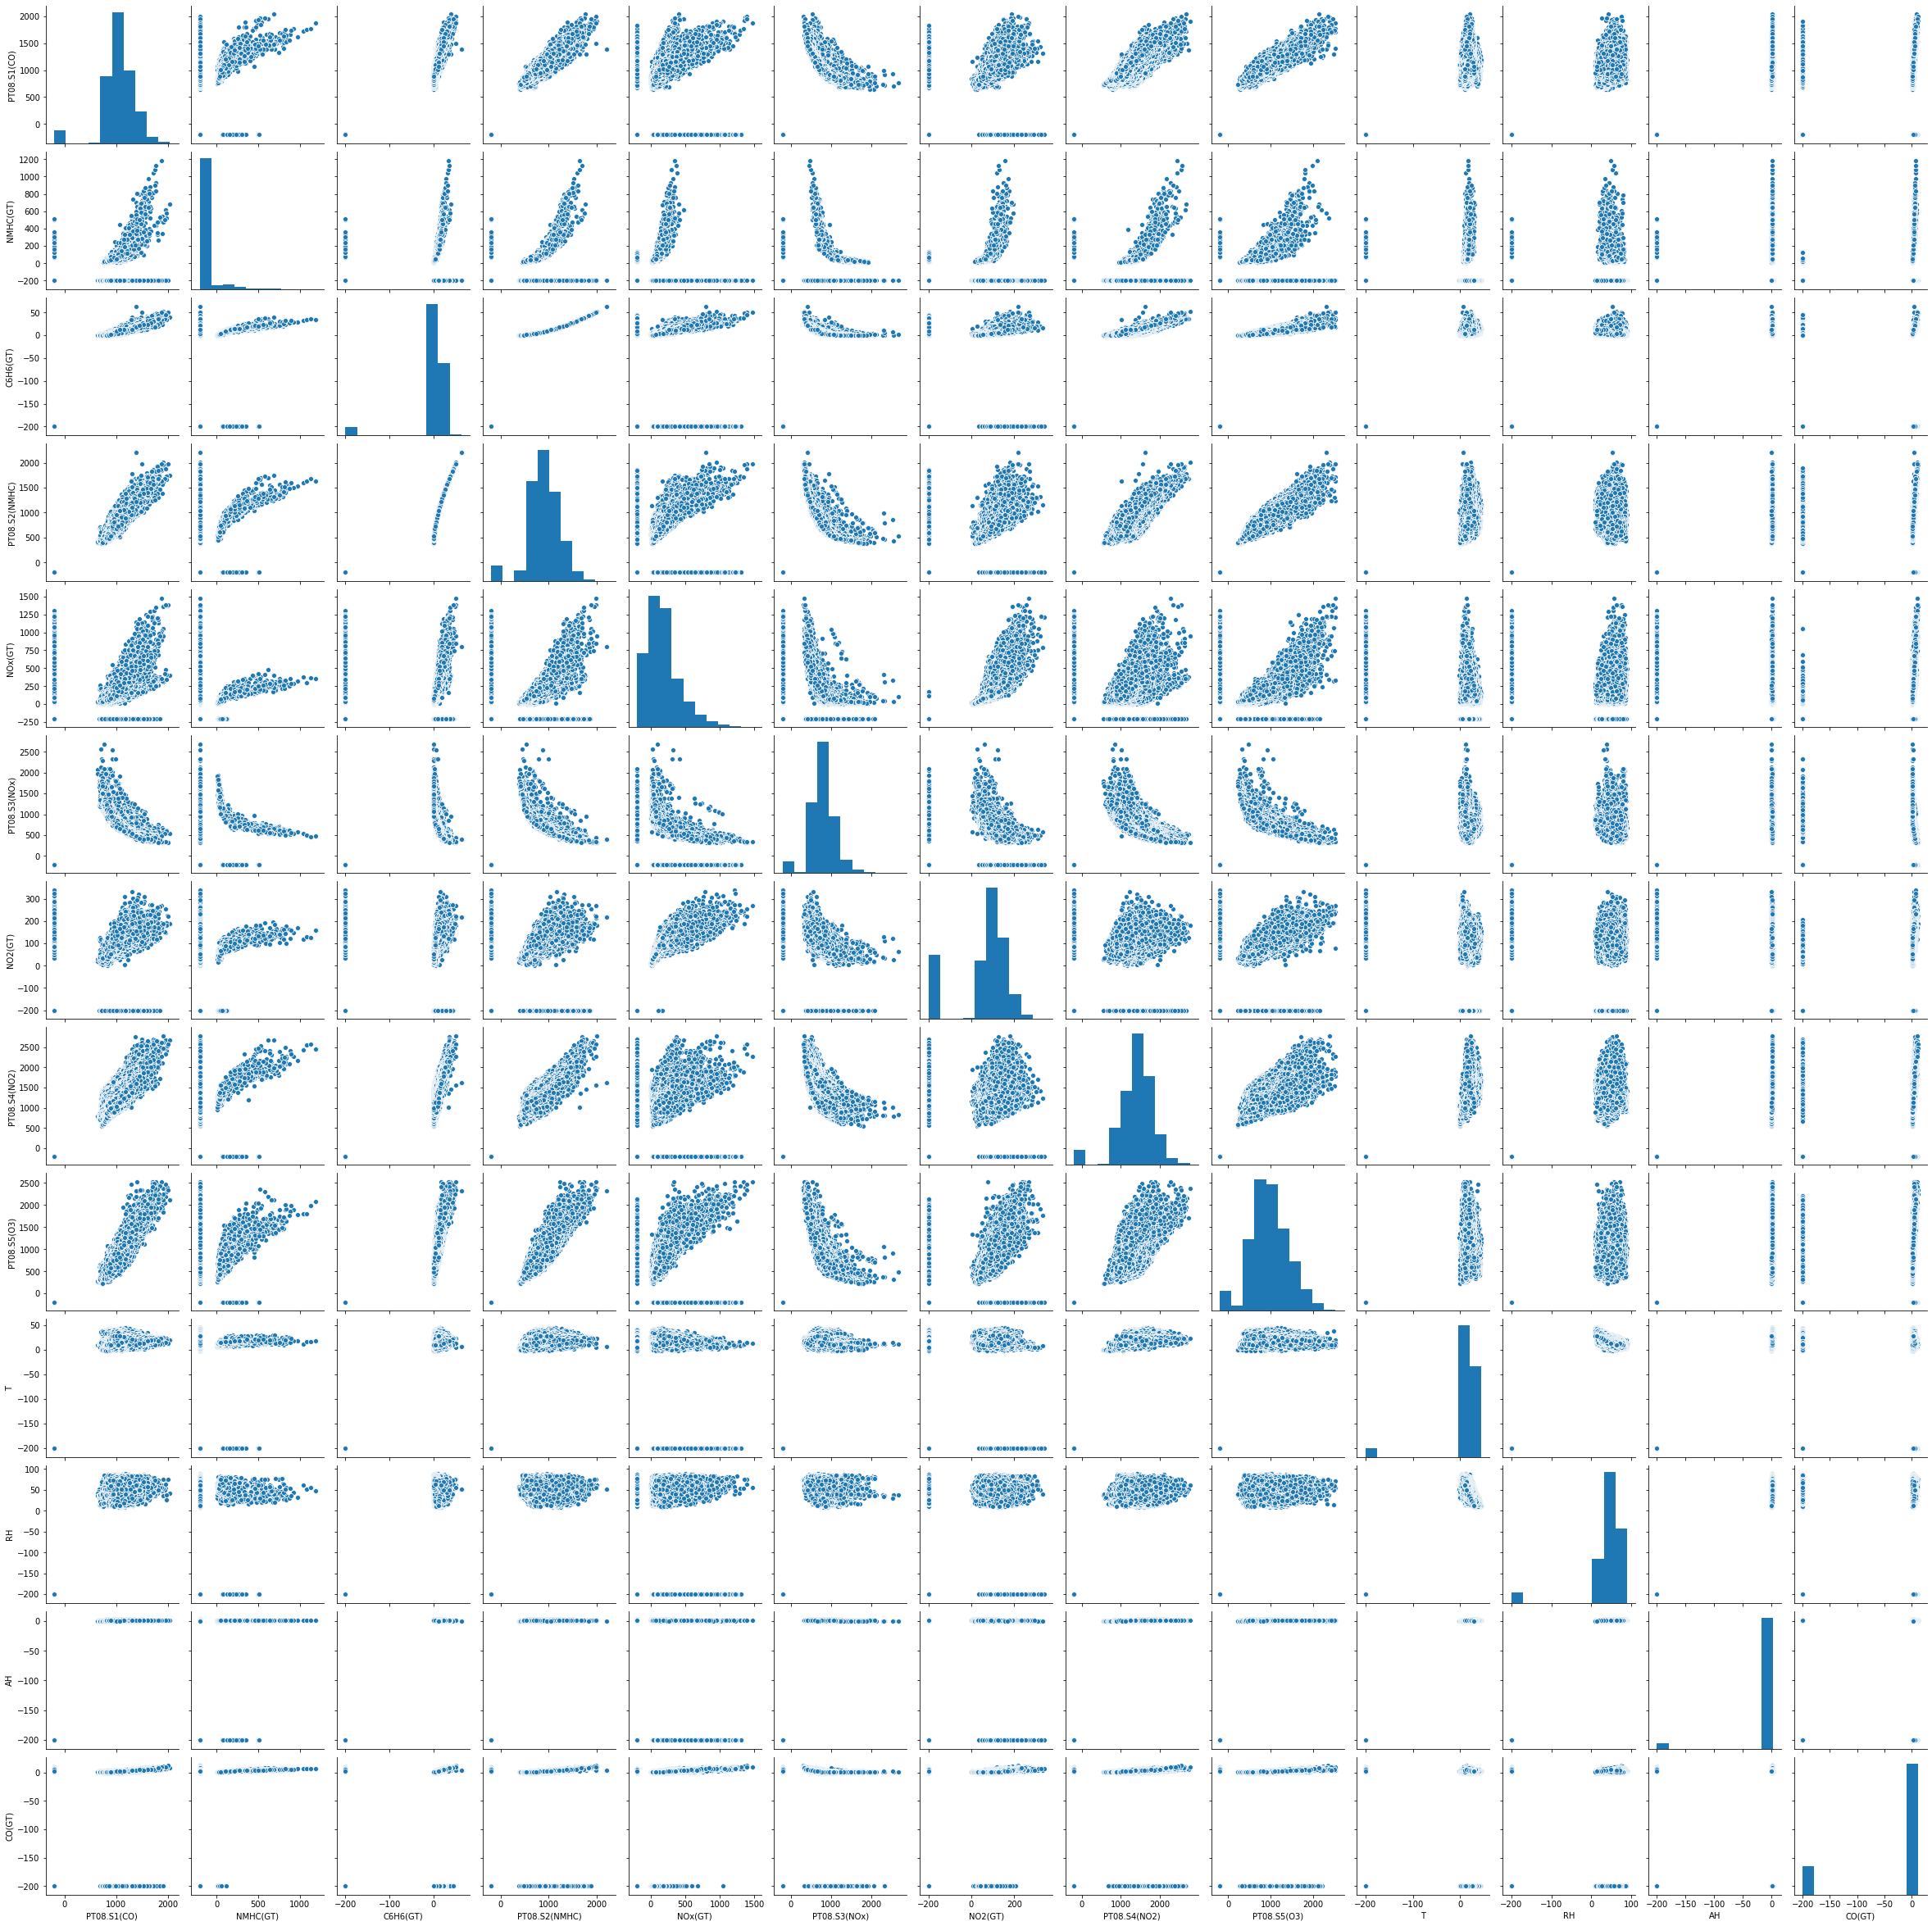

In [41]:
sns.pairplot(dataset)
plt.show()

In [73]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,train_size=0.8,test_size=0.2)


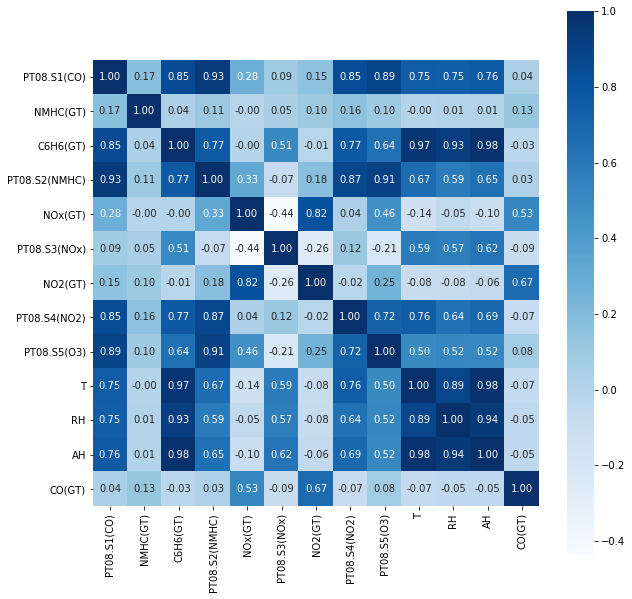

In [44]:
correlation = dataset.corr()

plt.figure(figsize=(10,10))
sns.heatmap(correlation, annot=True,fmt = '.2f', cmap="Blues",square=True)

In [45]:
from sklearn.linear_model import LinearRegression

mlr = LinearRegression()
mlr.fit(x_train,y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [54]:
y_predict = mlr.predict(x_test)
print(mlr.coef_)
print(mlr.intercept_)

[[-2.58576677e-04  4.53742255e-02 -5.08618007e-01 -2.20404428e-02
   3.67101116e-02  1.17477674e-02  3.85580817e-01  3.87941786e-03
  -8.74428562e-03  3.06071725e-01  1.79081915e-01  7.35437897e-02]]
[-50.68758287]


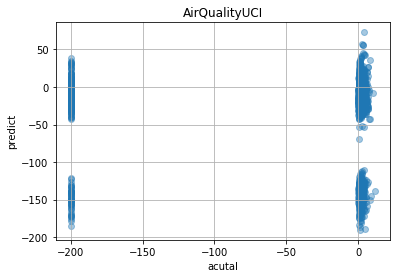

In [77]:
plt.title('AirQualityUCI')
plt.xlabel('acutal')
plt.ylabel('predict')
plt.grid(True)
plt.scatter(y_test,y_predict,alpha=0.4)
plt.show()


accuracy

In [79]:
print(mlr.score(x_test,y_test))


0.467217547469064


성능 RMSE

In [65]:
from sklearn.metrics import mean_squared_error

np.round(np.sqrt(mean_squared_error(y_test,y_predict)),2)

55.93